In [1]:
pip install xarray netcdf4 rioxarray matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
import matplotlib.pyplot as plt

### Uploading the files and printing the file details and variable details

In [3]:
pp = xr.open_dataset(r"D:\Projects\GNR644 - Water Balance\Precipitation\Rainfall_Resample_Cropped.nc")
ro = xr.open_dataset(r"D:\Projects\GNR644 - Water Balance\Runoff\Runoff_cropped_resampled.nc")

print(pp)
print(ro)

<xarray.Dataset> Size: 6MB
Dimensions:           (time: 297, lat: 67, lon: 73)
Coordinates:
  * time              (time) datetime64[ns] 2kB 2000-01-01 ... 2024-09-01
  * lat               (lat) float64 536B 8.25 8.5 8.75 9.0 ... 24.25 24.5 24.75
  * lon               (lon) float64 584B 72.75 73.0 73.25 ... 90.25 90.5 90.75
Data variables:
    spatial_ref       int64 8B ...
    satellite_precip  (time, lat, lon) float32 6MB ...
<xarray.Dataset> Size: 6MB
Dimensions:      (valid_time: 300, latitude: 67, longitude: 73)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 2kB 2000-01-01T06:00:00 ... 2024...
  * latitude     (latitude) float64 536B 24.75 24.5 24.25 24.0 ... 8.75 8.5 8.25
  * longitude    (longitude) float64 584B 72.75 73.0 73.25 ... 90.25 90.5 90.75
    number       int64 8B ...
    expver       (valid_time) <U4 5kB ...
Data variables:
    spatial_ref  int64 8B ...
    ro           (valid_time, latitude, longitude) float32 6MB ...


In [6]:
pp_var = pp['satellite_precip']
print("Precipitation", pp.data_vars)

ro_var = ro['ro']
print("Run off", ro.data_vars)

Precipitation Data variables:
    spatial_ref       int64 8B ...
    satellite_precip  (time, lat, lon) float32 6MB ...
Run off Data variables:
    spatial_ref  int64 8B ...
    ro           (valid_time, latitude, longitude) float32 6MB ...


### Plotting the Time Series map using the mean of Peninsular Basin

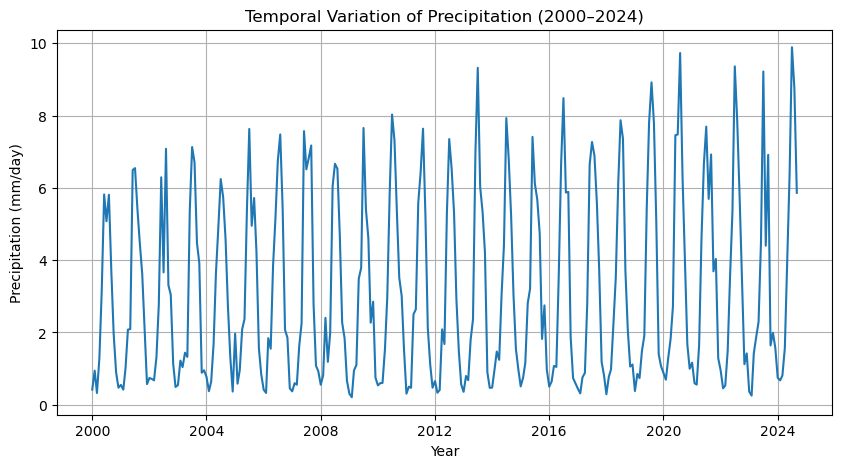

In [7]:
pp_ts = pp_var.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

pp_ts.plot(label='Precipitation')

plt.title("Temporal Variation of Precipitation (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm/day)")
plt.grid(True)

plt.show()

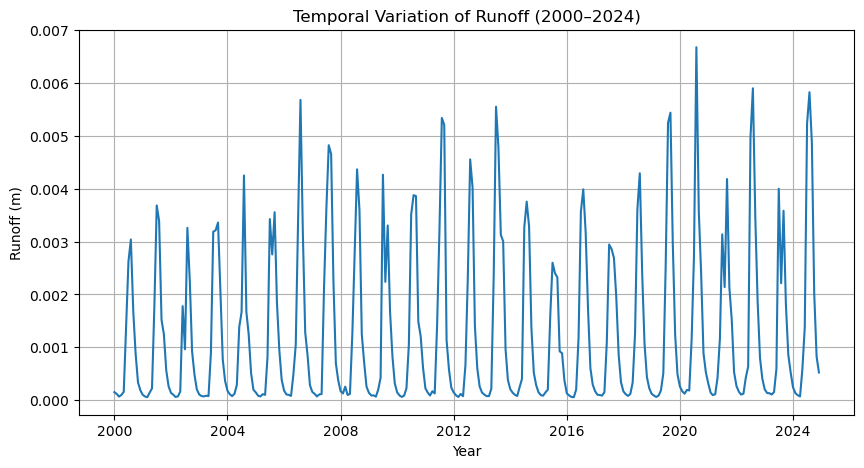

In [8]:
ro_ts = ro_var.mean(dim=['latitude','longitude'])
plt.figure(figsize=(10,5))

ro_ts.plot(label='Run Off')

plt.title("Temporal Variation of Runoff (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Runoff (m)")
plt.grid(True)

plt.show()

### Grouping the mean by Month

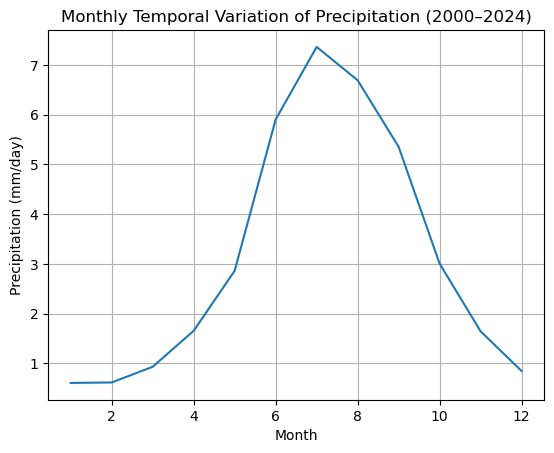

In [9]:
pp_season = pp_ts.groupby('time.month').mean()
pp_season.plot(label='Precipitation')
plt.title("Monthly Temporal Variation of Precipitation (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm/day)")
plt.grid(True)

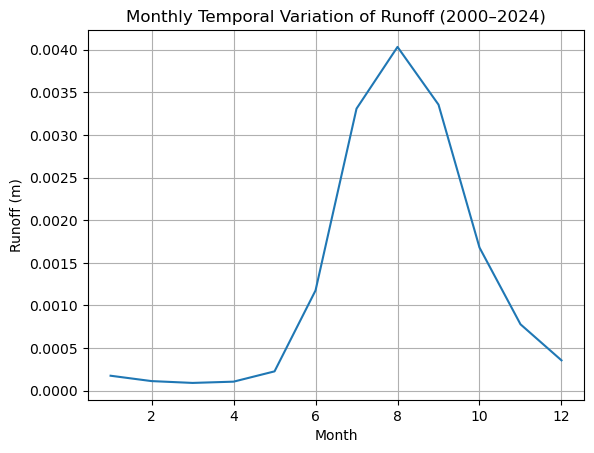

In [10]:
ro_season = ro_ts.groupby('valid_time.month').mean()
ro_season.plot(label='Runoff')
plt.title("Monthly Temporal Variation of Runoff (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Runoff (m)")
plt.grid(True)

### Trend Analysis

In [11]:
import numpy as np
from scipy.stats import linregress

time_pp = np.arange(len(pp_ts))

slope, intercept, r, p, std = linregress(time_pp, pp_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.0034008470676731113
p-value: 0.050651187592980165


Since the slope is greater than 0, it is increasing

In [12]:
time_ro = np.arange(len(ro_ts))

slope, intercept, r, p, std = linregress(time_ro, ro_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 1.8068062192393302e-06
p-value: 0.07680066646393523


It has a increasing trend

### Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [13]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Precipitation from 2000 to 2024')

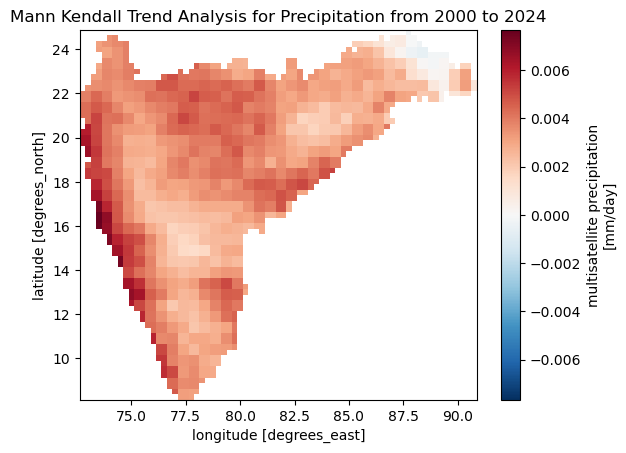

In [14]:
pp_trend = xr.apply_ufunc(
    trend_calc,
    pp_var,
    input_core_dims=[['time']],
    vectorize=True
)

pp_trend.plot()
plt.title("Mann Kendall Trend Analysis for Precipitation from 2000 to 2024")

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Runoff from 2000 to 2024')

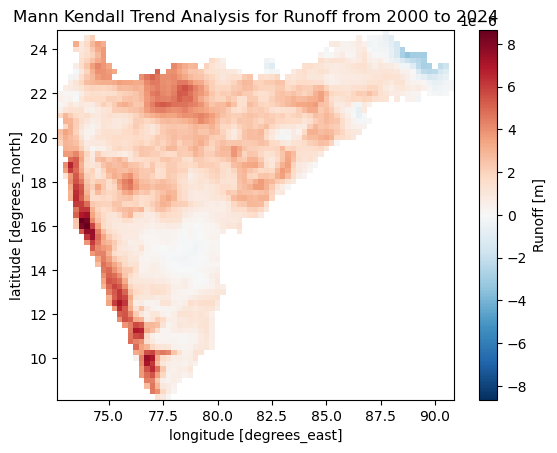

In [15]:
ro_trend = xr.apply_ufunc(
    trend_calc,
    ro_var,
    input_core_dims=[['valid_time']],
    vectorize=True
)

ro_trend.plot()
plt.title("Mann Kendall Trend Analysis for Runoff from 2000 to 2024")

### Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for Precipitation')

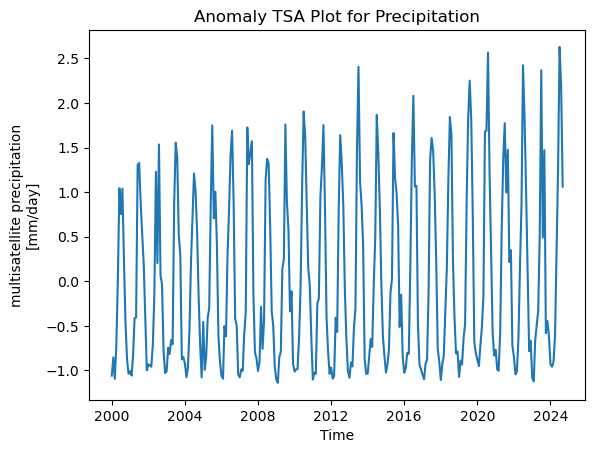

In [20]:
pp_mean = pp_ts.mean()
pp_std = pp_ts.std()
pp_anomaly = pp_ts - pp_mean
pp_std_anomaly = (pp_ts - pp_mean) / pp_std
pp_std_anomaly.plot()
plt.title("Anomaly TSA Plot for Precipitation") 

Text(0.5, 1.0, 'Anomaly TSA Plot for Runoff')

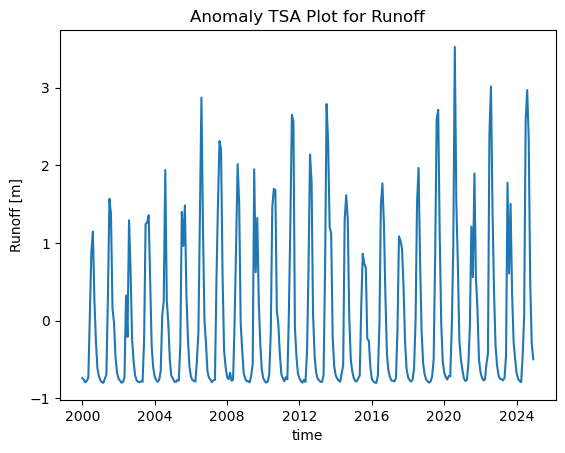

In [18]:
ro_mean = ro_ts.mean()
ro_std = ro_ts.std()
ro_std_anomaly = (ro_ts - ro_mean) / ro_std
ro_std_anomaly.plot()
plt.title("Anomaly TSA Plot for Runoff") 